Notebook 06 — Model Comparison

Final comparison of all three forecasting approaches: persistence baseline, Prophet, and LightGBM, evaluated via the same walk-forward CV harness (365-day min train, 30-day horizon, 30-day step) across all 5 cities.

SARIMA (`m=365`) was attempted as a Delhi-only proof of concept but did not complete within a single Colab runtime session due to computational cost — excluded from this comparison. Prophet serves as the primary classical benchmark.

In [1]:
import pandas as pd

comparison = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru'],
    'persistence_mae':  [45.07, 17.56, 12.81, 15.54, 11.52],
    'prophet_mae':      [37.38, 17.54, 15.40, 12.71, 11.08],
    'lightgbm_mae':     [25.74, 10.13,  6.60,  7.29,  7.45],
    'persistence_rmse': [55.01, 21.02, 15.86, 18.22, 15.62],
    'prophet_rmse':     [46.51, 21.29, 20.19, 15.11, 14.80],
    'lightgbm_rmse':    [34.27, 13.14,  9.33,  8.99, 11.37],
})

comparison

,city,persistence_mae,prophet_mae,lightgbm_mae,persistence_rmse,prophet_rmse,lightgbm_rmse
0,Delhi,45.07,37.38,25.74,55.01,46.51,34.27
1,Mumbai,17.56,17.54,10.13,21.02,21.29,13.14
2,Chennai,12.81,15.40,6.60,15.86,20.19,9.33
3,Hyderabad,15.54,12.71,7.29,18.22,15.11,8.99
4,Bengaluru,11.52,11.08,7.45,15.62,14.80,11.37


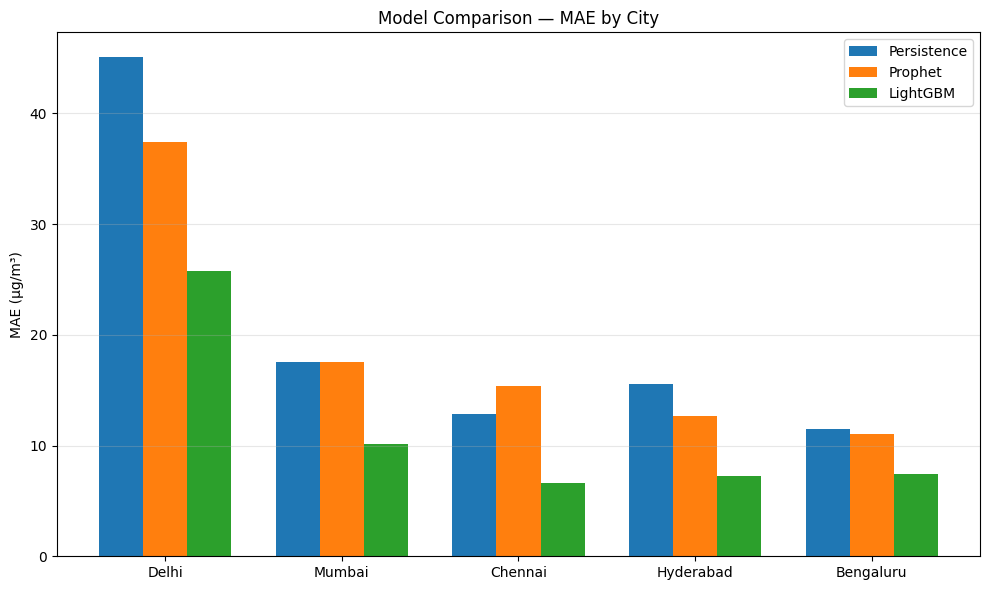

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison['city']))
width = 0.25

ax.bar(x - width, comparison['persistence_mae'], width, label='Persistence')
ax.bar(x,          comparison['prophet_mae'],     width, label='Prophet')
ax.bar(x + width,  comparison['lightgbm_mae'],     width, label='LightGBM')

ax.set_xticks(x)
ax.set_xticklabels(comparison['city'])
ax.set_ylabel('MAE (µg/m³)')
ax.set_title('Model Comparison — MAE by City')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model_comparison_mae.png', dpi=150)
plt.show()

## Results Summary

LightGBM outperforms both baselines across every city, with the largest gains in Delhi (−31% MAE vs Prophet) and Chennai (−57% MAE vs Prophet, which itself lost to persistence there). Feature importance analysis confirms the model is learning sensible patterns — `lag_1` dominates as expected, followed by seasonal (`doy_cos`) and trend (`roll_mean_7/14/30`) features, with no evidence of the accepted outlier-flag leakage driving results.

## Known Limitations

- **SARIMA excluded**: attempted as a Delhi-only proof of concept (`m=365`, single 80/20 split) but did not complete within a single Colab runtime session. Prophet serves as the primary classical benchmark instead.
- **Seasonal error degradation**: per-fold MAE over time shows LightGBM's errors rise consistently during Oct–Feb in Delhi and Hyderabad — the same winter pollution season flagged as most extreme and erratic in EDA. The model captures the general seasonal shift (via calendar features) but individual peak-day magnitudes remain harder to predict precisely than the calmer rest of the year.
- **One-off event sensitivity**: Bengaluru's worst fold (ending 2023-02-13) shows a large MAE/RMSE gap (33 vs 103), diagnostic of a single extreme miss rather than broad unreliability — traced to the Jan 26 2023 Republic Day spike (556 µg/m³), an unprecedented magnitude the model had never seen in training and so could not extrapolate to.
- **Outlier flag leakage**: `is_outlier` computed on full-series statistics rather than per-fold expanding windows — a minor, accepted simplification for a binary feature, confirmed not to be driving results via feature importance.